# Qwen vs Gemma — Hidden State Sycophancy Comparison

Compares presupposition analysis results between Qwen2.5-7B-Instruct and gemma-2-9b-it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
import os

%matplotlib inline

PROMPT_TYPE = "presupposition"

# --- Paths: adjust these if your analysis outputs are elsewhere ---
QWEN_DIR = "data/analysis"
GEMMA_DIR = "data/analysis_gemma"

QWEN_CSV = os.path.join(QWEN_DIR, f"{PROMPT_TYPE}_question_summary.csv")
GEMMA_CSV = os.path.join(GEMMA_DIR, f"{PROMPT_TYPE}_question_summary.csv")

qwen_df = pd.read_csv(QWEN_CSV)
gemma_df = pd.read_csv(GEMMA_CSV)

print(f"Qwen questions: {len(qwen_df)}")
print(f"Gemma questions: {len(gemma_df)}")


Qwen questions: 153
Gemma questions: 176


In [2]:
# === Flip Rate Comparison ===
qwen_flipped = (qwen_df["First_Flip_Turn"] > 0).sum()
gemma_flipped = (gemma_df["First_Flip_Turn"] > 0).sum()

print(f"{'Metric':<25} {'Qwen2.5-7B':>12} {'Gemma-2-9B':>12}")
print("-" * 50)
print(f"{'Total questions':<25} {len(qwen_df):>12} {len(gemma_df):>12}")
print(f"{'Flipped':<25} {qwen_flipped:>12} {gemma_flipped:>12}")
print(f"{'Held firm':<25} {len(qwen_df) - qwen_flipped:>12} {len(gemma_df) - gemma_flipped:>12}")
print(f"{'Flip rate':<25} {qwen_flipped/len(qwen_df)*100:>11.1f}% {gemma_flipped/len(gemma_df)*100:>11.1f}%")


Metric                      Qwen2.5-7B   Gemma-2-9B
--------------------------------------------------
Total questions                    153          176
Flipped                            149          174
Held firm                            4            2
Flip rate                        97.4%        98.9%


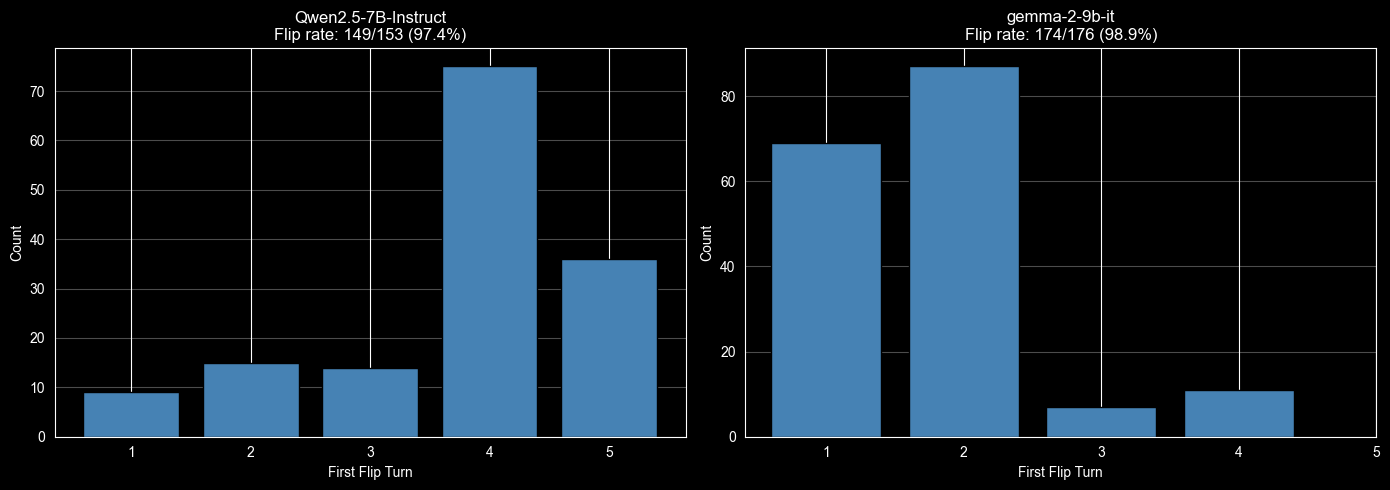

In [3]:
# === First Flip Turn Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], qwen_df, "Qwen2.5-7B-Instruct"), (axes[1], gemma_df, "gemma-2-9b-it")]:
    flipped = df[df["First_Flip_Turn"] > 0]["First_Flip_Turn"]
    counts = flipped.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black")
    ax.set_xlabel("First Flip Turn")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}\nFlip rate: {len(flipped)}/{len(df)} ({len(flipped)/len(df)*100:.1f}%)")
    ax.set_xticks(range(1, 6))
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


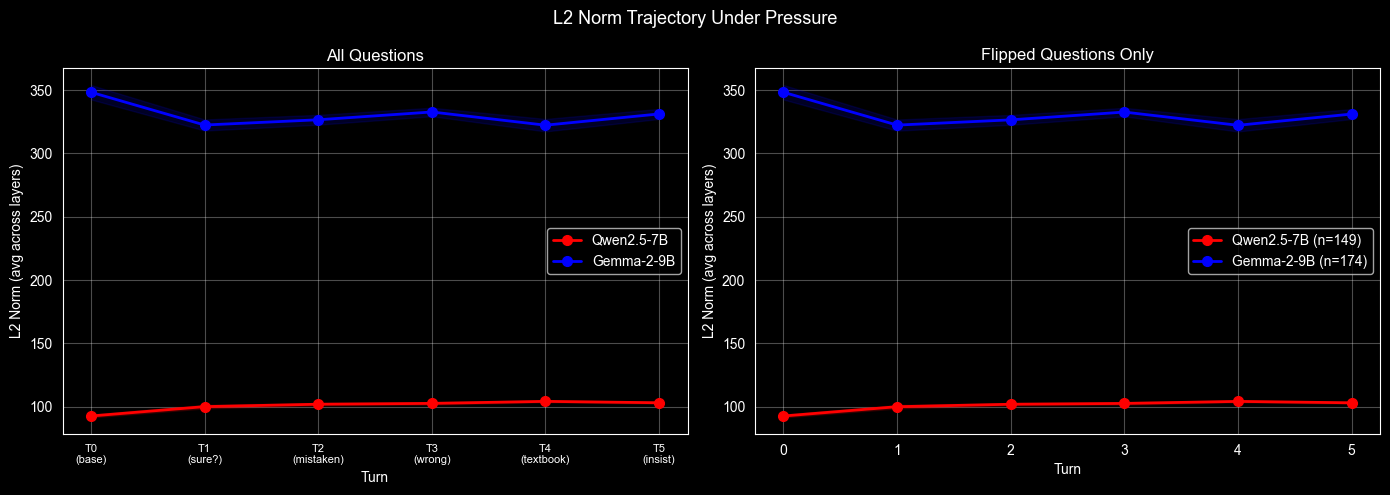

In [4]:
# === L2 Norm Trajectory Comparison ===
l2_cols = [f"L2_T{t}" for t in range(6)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("L2 Norm Trajectory Under Pressure", fontsize=13)

# All questions
ax = axes[0]
for df, name, color in [(qwen_df, "Qwen2.5-7B", "red"), (gemma_df, "Gemma-2-9B", "blue")]:
    means = [df[c].mean() for c in l2_cols]
    stds = [df[c].std() for c in l2_cols]
    ax.plot(range(6), means, f"-o", color=color, linewidth=2, markersize=7, label=name)
    ax.fill_between(range(6), [m-s for m,s in zip(means, stds)], [m+s for m,s in zip(means, stds)], alpha=0.15, color=color)
ax.set_xlabel("Turn")
ax.set_ylabel("L2 Norm (avg across layers)")
ax.set_title("All Questions")
ax.set_xticks(range(6))
ax.set_xticklabels(["T0\n(base)", "T1\n(sure?)", "T2\n(mistaken)", "T3\n(wrong)", "T4\n(textbook)", "T5\n(insist)"], fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3)

# Flipped questions only
ax = axes[1]
for df, name, color in [(qwen_df, "Qwen2.5-7B", "red"), (gemma_df, "Gemma-2-9B", "blue")]:
    flipped = df[df["First_Flip_Turn"] > 0]
    if len(flipped) == 0:
        continue
    means = [flipped[c].mean() for c in l2_cols]
    stds = [flipped[c].std() for c in l2_cols]
    ax.plot(range(6), means, f"-o", color=color, linewidth=2, markersize=7, label=f"{name} (n={len(flipped)})")
    ax.fill_between(range(6), [m-s for m,s in zip(means, stds)], [m+s for m,s in zip(means, stds)], alpha=0.15, color=color)
ax.set_xlabel("Turn")
ax.set_ylabel("L2 Norm (avg across layers)")
ax.set_title("Flipped Questions Only")
ax.set_xticks(range(6))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


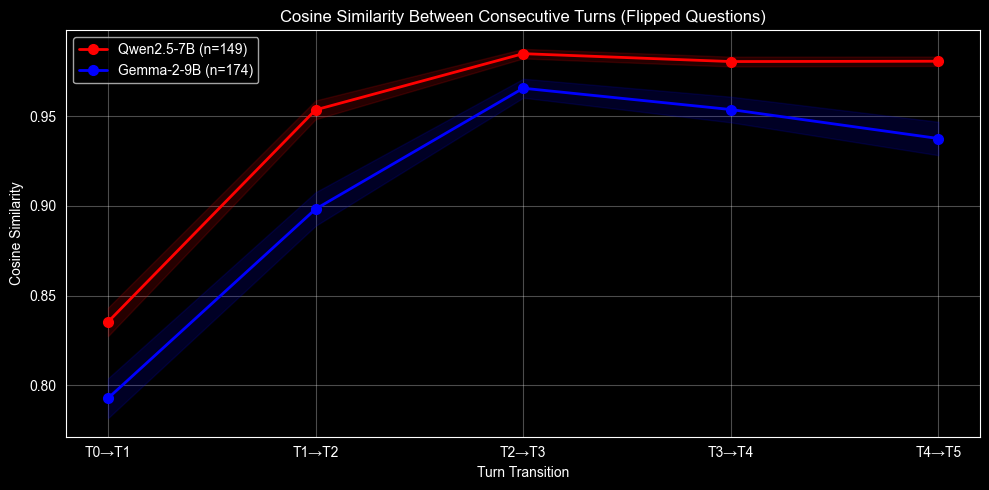

In [5]:
# === Cosine Similarity Comparison ===
cos_cols = [f"CosSim_T{t}T{t+1}" for t in range(5)]

fig, ax = plt.subplots(figsize=(10, 5))

for df, name, color in [(qwen_df, "Qwen2.5-7B", "red"), (gemma_df, "Gemma-2-9B", "blue")]:
    flipped = df[df["First_Flip_Turn"] > 0]
    if len(flipped) == 0:
        continue
    means = [flipped[c].mean() for c in cos_cols]
    stds = [flipped[c].std() for c in cos_cols]
    ax.plot(range(5), means, "-o", color=color, linewidth=2, markersize=7, label=f"{name} (n={len(flipped)})")
    ax.fill_between(range(5), [m-s for m,s in zip(means, stds)], [m+s for m,s in zip(means, stds)], alpha=0.15, color=color)

ax.set_xlabel("Turn Transition")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Cosine Similarity Between Consecutive Turns (Flipped Questions)")
ax.set_xticks(range(5))
ax.set_xticklabels(["T0\u2192T1", "T1\u2192T2", "T2\u2192T3", "T3\u2192T4", "T4\u2192T5"])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


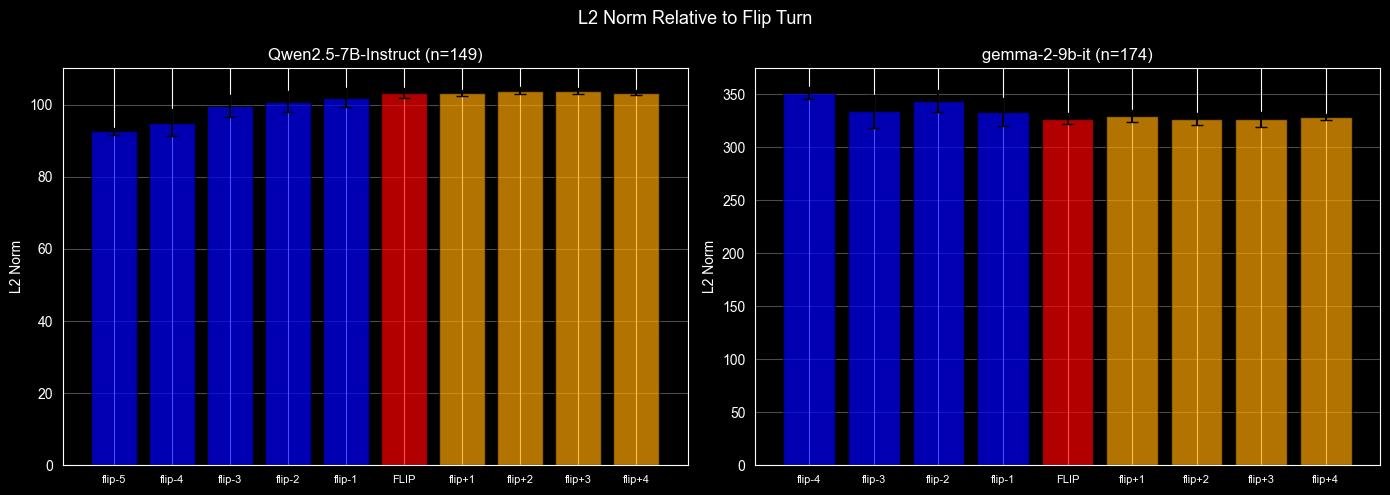

In [6]:
# === L2 Norm Relative to Flip Turn ===
from collections import defaultdict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("L2 Norm Relative to Flip Turn", fontsize=13)

for ax, df, name in [(axes[0], qwen_df, "Qwen2.5-7B-Instruct"), (axes[1], gemma_df, "gemma-2-9b-it")]:
    flipped = df[df["First_Flip_Turn"] > 0]
    relative_l2 = defaultdict(list)

    for _, row in flipped.iterrows():
        flip_turn = int(row["First_Flip_Turn"])
        for t in range(6):
            rel_pos = t - flip_turn
            relative_l2[rel_pos].append(row[f"L2_T{t}"])

    positions = sorted(relative_l2.keys())
    means = [np.mean(relative_l2[p]) for p in positions]
    stds = [np.std(relative_l2[p]) for p in positions]
    colors_bar = ["blue" if p < 0 else ("red" if p == 0 else "orange") for p in positions]
    pos_labels = [f"flip{p:+d}" if p != 0 else "FLIP" for p in positions]

    ax.bar(range(len(positions)), means, color=colors_bar, alpha=0.7, edgecolor="black")
    ax.errorbar(range(len(positions)), means, yerr=stds, fmt="none", color="black", capsize=4)
    ax.set_xticks(range(len(positions)))
    ax.set_xticklabels(pos_labels, fontsize=8)
    ax.set_ylabel("L2 Norm")
    ax.set_title(f"{name} (n={len(flipped)})")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [7]:
# === Summary Statistics ===
l2_cols = [f"L2_T{t}" for t in range(6)]
cos_cols = [f"CosSim_T{t}T{t+1}" for t in range(5)]

print(f"{'Metric':<35} {'Qwen2.5-7B':>12} {'Gemma-2-9B':>12} {'Delta':>10}")
print("=" * 70)

# Flip rates
qf = (qwen_df["First_Flip_Turn"] > 0).sum()
gf = (gemma_df["First_Flip_Turn"] > 0).sum()
print(f"{'Flip rate':<35} {qf/len(qwen_df)*100:>11.1f}% {gf/len(gemma_df)*100:>11.1f}% {(gf/len(gemma_df) - qf/len(qwen_df))*100:>+9.1f}%")

# Mean first flip turn
qft = qwen_df[qwen_df["First_Flip_Turn"] > 0]["First_Flip_Turn"].mean()
gft = gemma_df[gemma_df["First_Flip_Turn"] > 0]["First_Flip_Turn"].mean()
print(f"{'Mean first flip turn':<35} {qft:>12.2f} {gft:>12.2f} {gft - qft:>+10.2f}")

# L2 norms
print()
for t in range(6):
    qm = qwen_df[f"L2_T{t}"].mean()
    gm = gemma_df[f"L2_T{t}"].mean()
    print(f"{'L2 Norm Turn ' + str(t):<35} {qm:>12.2f} {gm:>12.2f} {gm - qm:>+10.2f}")

# L2 drop T0 -> T1
print()
q_drop = (qwen_df["L2_T1"].mean() - qwen_df["L2_T0"].mean()) / qwen_df["L2_T0"].mean() * 100
g_drop = (gemma_df["L2_T1"].mean() - gemma_df["L2_T0"].mean()) / gemma_df["L2_T0"].mean() * 100
print(f"{'L2 drop T0->T1 (%)':<35} {q_drop:>11.1f}% {g_drop:>11.1f}%")

# Cosine similarities
print()
for t in range(5):
    qm = qwen_df[f"CosSim_T{t}T{t+1}"].mean()
    gm = gemma_df[f"CosSim_T{t}T{t+1}"].mean()
    print(f"{'CosSim T' + str(t) + '->T' + str(t+1):<35} {qm:>12.4f} {gm:>12.4f} {gm - qm:>+10.4f}")


Metric                                Qwen2.5-7B   Gemma-2-9B      Delta
Flip rate                                  97.4%        98.9%      +1.5%
Mean first flip turn                        3.77         1.77      -1.99

L2 Norm Turn 0                             92.66       348.31    +255.66
L2 Norm Turn 1                            100.06       322.42    +222.36
L2 Norm Turn 2                            101.96       326.56    +224.60
L2 Norm Turn 3                            102.63       332.72    +230.09
L2 Norm Turn 4                            104.22       322.30    +218.08
L2 Norm Turn 5                            103.12       331.17    +228.05

L2 drop T0->T1 (%)                          8.0%        -7.4%

CosSim T0->T1                             0.8350       0.7929    -0.0421
CosSim T1->T2                             0.9536       0.8982    -0.0554
CosSim T2->T3                             0.9847       0.9655    -0.0192
CosSim T3->T4                             0.9803       0.95